# Housing Rent Prediction


> We will apply linear regression to predict rent price of houses based on their features.

> Features are listed below in the dataset explanation, our **target** column is ***Rent***.


> dataset link: https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset/data


> If you have any questions or feel stuck, send in the group anytime




# Dataset Explanation



> BHK: عدد غرف النوم, الصالة و المطبخ

> Rent: سعر إيجار البيت

> Size: حجم البيت (square feet)

> Floor: البيت في الدور الكام و العمارة كلها كام دور

> Area type: عبارة عن حجم البيت بس مصنف ل 3 فئات مختلفة (super area / carpet area / build area )

> Area Locality: المنطقة البيت موجود فيها

> City: المدينة البيت موجود فيها

> Furnishing Status: البيت مفروش قد ايه

> Tenant Preferred: صاحب البيت بيفضل ان الشخص ال هيأجر يكون عنده بكلريوس او عنده اسرة عشان يكون مهتم بدفع الإيجار

> Bathroom: عدد الحمامات في البيت

> Point of Contact: هتكلم مين لو عندك سؤال عن البيت
























# Below cell is setup, you can ignore it

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('House_Rent_Dataset.csv')

renaming = {
    'Posted On': 'Posted_On',
    'Area Type': 'Area_Type',
    'Area Locality': 'Area_Locality',
    'Furnishing Status': 'Furnishing_Status',
    'Tenant Preferred': 'Tenant_Preferred',
    'Point of Contact': 'Point_of_Contact'
}

df.rename(columns=renaming, inplace=True)

df['Posted_On'] = pd.to_datetime(df['Posted_On'])


# Start here !

---

**Remember main steps:**


1.   Apply EDA:

*   Find important features and use them
*   Extract relationships between variables and target column
*   Try to deal with outliers if there are any


2.   Apply preprocessing (Data Scaling and Encoding)


*   Make sure all numeric features are on the same scale
*   remember: models *do not understand* strings

3.   Use Linear Regression !


*   Predict the rent price
*   If results are not satisfying, work more on previous steps and try training models again
*   Use Lasso/Ridge to possibly achieve higher accuracy ( Bonus )






In [3]:
df.head()

,Posted_On,BHK,Rent,Size,Floor,Area_Type,Area_Locality,City,Furnishing_Status,Tenant_Preferred,Bathroom,Point_of_Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [4]:
df.shape

(4746, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Posted_On          4746 non-null   datetime64[us]
 1   BHK                4746 non-null   int64         
 2   Rent               4746 non-null   int64         
 3   Size               4746 non-null   int64         
 4   Floor              4746 non-null   str           
 5   Area_Type          4746 non-null   str           
 6   Area_Locality      4746 non-null   str           
 7   City               4746 non-null   str           
 8   Furnishing_Status  4746 non-null   str           
 9   Tenant_Preferred   4746 non-null   str           
 10  Bathroom           4746 non-null   int64         
 11  Point_of_Contact   4746 non-null   str           
dtypes: datetime64[us](1), int64(4), str(7)
memory usage: 445.1 KB


In [6]:
df.isnull().sum()

Posted_On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area_Type            0
Area_Locality        0
City                 0
Furnishing_Status    0
Tenant_Preferred     0
Bathroom             0
Point_of_Contact     0
dtype: int64

==> no null values

In [7]:
df.dtypes

Posted_On            datetime64[us]
BHK                           int64
Rent                          int64
Size                          int64
Floor                           str
Area_Type                       str
Area_Locality                   str
City                            str
Furnishing_Status               str
Tenant_Preferred                str
Bathroom                      int64
Point_of_Contact                str
dtype: object

In [8]:
df.describe()

,Posted_On,BHK,Rent,Size,Bathroom
count,4746,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2022-06-07 18:01:40.126422,2.083860,3.499345e+04,967.490729,1.965866
min,2022-04-13 00:00:00,1.000000,1.200000e+03,10.000000,1.000000
25%,2022-05-20 00:00:00,2.000000,1.000000e+04,550.000000,1.000000
50%,2022-06-10 00:00:00,2.000000,1.600000e+04,850.000000,2.000000
75%,2022-06-28 00:00:00,3.000000,3.300000e+04,1200.000000,2.000000
max,2022-07-11 00:00:00,6.000000,3.500000e+06,8000.000000,10.000000
std,NaN,0.832256,7.810641e+04,634.202328,0.884532


In [9]:
df.describe(include=object)

C:\Users\pc\AppData\Local\Temp\ipykernel_17468\3998025828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=object)


,Floor,Area_Type,Area_Locality,City,Furnishing_Status,Tenant_Preferred,Point_of_Contact
count,4746,4746,4746,4746,4746,4746,4746
unique,480,3,2235,6,3,3,3
top,1 out of 2,Super Area,Bandra West,Mumbai,Semi-Furnished,Bachelors/Family,Contact Owner
freq,379,2446,37,972,2251,3444,3216


In [10]:
df.duplicated().sum()

np.int64(0)

==> no duplicated

In [11]:
df.Rent.describe()

count    4.746000e+03
mean     3.499345e+04
std      7.810641e+04
min      1.200000e+03
25%      1.000000e+04
50%      1.600000e+04
75%      3.300000e+04
max      3.500000e+06
Name: Rent, dtype: float64

<Axes: >

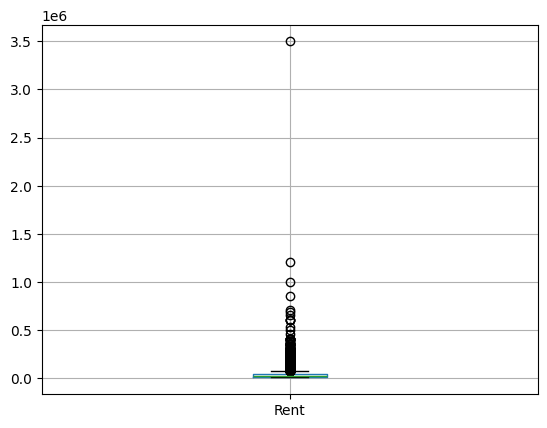

In [12]:
df.boxplot(column='Rent')

outliers detection for BHK column

In [13]:
df.BHK.describe()

count    4746.000000
mean        2.083860
std         0.832256
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: BHK, dtype: float64

In [14]:
df.boxplot(column='BHK')

<Axes: >

In [15]:
# from the boxPlot : there is no lower_outliers
Q1 = df.BHK.quantile(0.25)
Q3 = df.BHK.quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR


In [16]:
df.BHK[(df.BHK > upper_limit)].count()

np.int64(27)

In [17]:
# for checking
df.BHK[(df.BHK > upper_limit)].count()

np.int64(27)

outliers detection for size column

In [18]:
df.Size.describe()

count    4746.000000
mean      967.490729
std       634.202328
min        10.000000
25%       550.000000
50%       850.000000
75%      1200.000000
max      8000.000000
Name: Size, dtype: float64

In [19]:
df.boxplot(column='Size')

<Axes: >

In [20]:
# there is many upper_outliers but no lower_outliers
Q1 = df.Size.quantile(0.25)
Q3 = df.Size.quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
upper_limit


np.float64(2175.0)

In [21]:
df.Size[(df.Size > upper_limit)].count()

np.int64(203)

==> large number to change it without bias

In [22]:
# scaling the size column
df.Size = (df.Size - df.Size.mean()) / df.Size.std()

outliers detection for Bathroom column

In [23]:
df.Bathroom.describe()


count    4746.000000
mean        1.965866
std         0.884532
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max        10.000000
Name: Bathroom, dtype: float64

In [24]:
df.boxplot(column='Bathroom')


<Axes: >

In [25]:
# there is no lower_outliers
Q1 = df.Bathroom.quantile(0.25)
Q3 = df.Bathroom.quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
upper_limit


np.float64(3.5)

In [26]:
df.Bathroom[(df.Bathroom > upper_limit)].count()

np.int64(232)

==> large number

numerical correlations

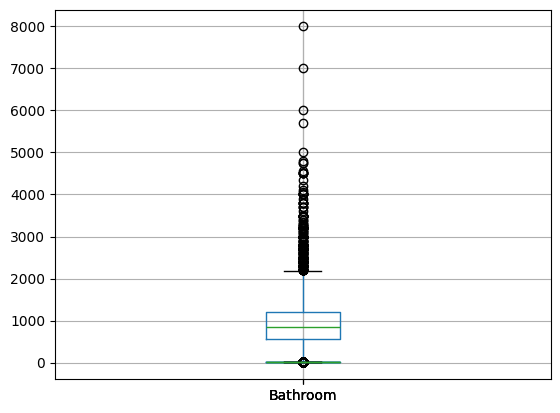

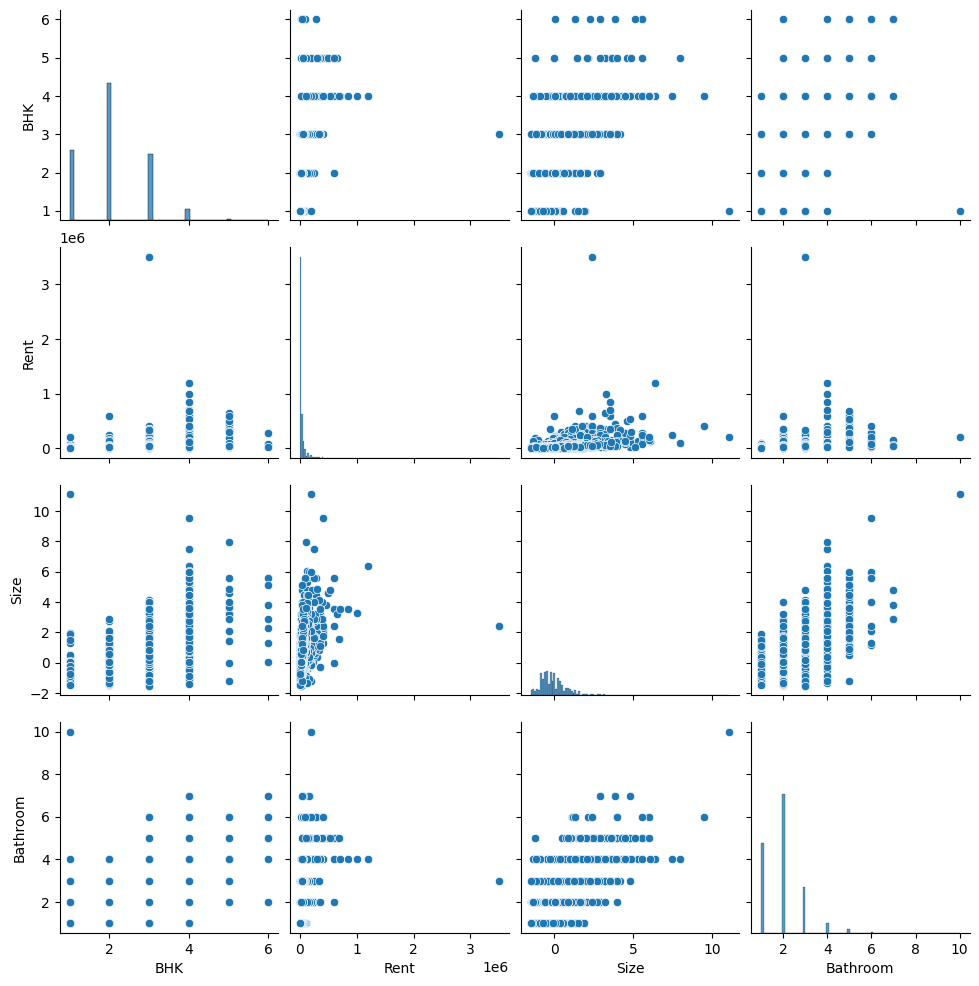

In [27]:
sns.pairplot(data=df)
plt.show()

In [28]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: >

==> the most numerical column that influences the target column is the Bathroom column, but all of the numerical columns are influence the target column strongly

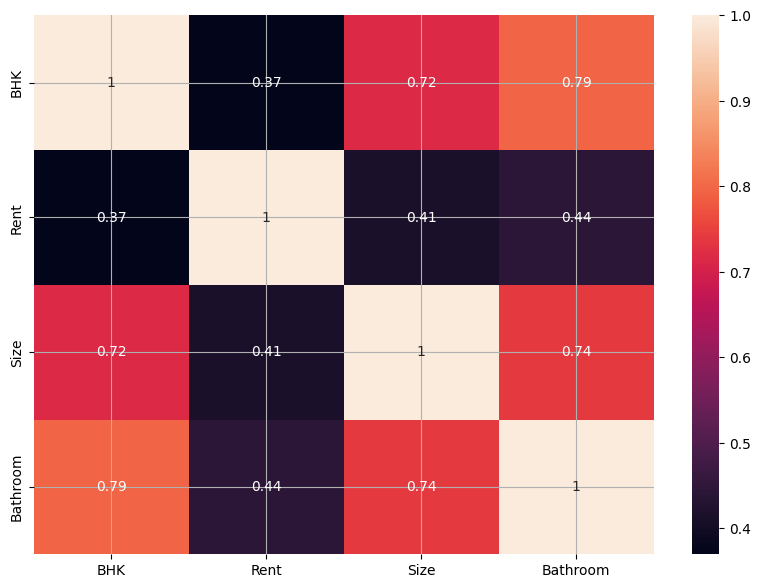

In [29]:
df['Posted_On'].hist(bins=30, figsize=(10,7))
plt.show()

==> the data in Posted_On column shows the change in small range that can be eliminated

In [30]:
df = df.drop('Posted_On', axis=1)

Analyzing categorical features

In [31]:
df.Floor.describe()

count           4746
unique           480
top       1 out of 2
freq             379
Name: Floor, dtype: object

it is very hard to deal with, since it has many unique values

In [32]:
df = df.drop('Floor', axis=1)

In [33]:
df.Area_Type.describe()


count           4746
unique             3
top       Super Area
freq            2446
Name: Area_Type, dtype: object

In [34]:
df['Area_Type'].value_counts()

Area_Type
Super Area     2446
Carpet Area    2298
Built Area        2
Name: count, dtype: int64

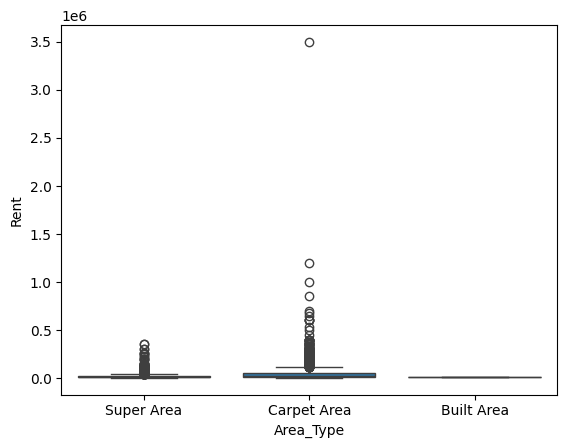

In [35]:
sns.boxplot(x='Area_Type', y='Rent', data=df)
plt.show()

In [36]:
df.groupby('Area_Type')['Rent'].mean()

Area_Type
Built Area     10500.000000
Carpet Area    52385.897302
Super Area     18673.396566
Name: Rent, dtype: float64

==> the target column affected by the Area_Type : 'Carpet Area' more than the other types

In [37]:
# encoding the Area_Type column
mapper = {
    'Carpet Area': 0,
    'Super Area': 2,
    'Built Area': 1
}
if (df.Area_Type.dtype != 'int64'):
  df['Area_Type'] = df['Area_Type'].map(mapper)
df.head()

,BHK,Rent,Size,Area_Type,Area_Locality,City,Furnishing_Status,Tenant_Preferred,Bathroom,Point_of_Contact
0,2,10000,0.208938,2,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,-0.264097,2,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,0.051260,2,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,-0.264097,2,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,-0.185257,0,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [38]:
df.Area_Locality.describe()


count            4746
unique           2235
top       Bandra West
freq               37
Name: Area_Locality, dtype: object


it is very hard to deal with, since it has many unique values

In [39]:
df = df.drop('Area_Locality', axis=1)

In [40]:
df.City.describe()

count       4746
unique         6
top       Mumbai
freq         972
Name: City, dtype: object

In [41]:
df['City'].value_counts()

City
Mumbai       972
Chennai      891
Bangalore    886
Hyderabad    868
Delhi        605
Kolkata      524
Name: count, dtype: int64

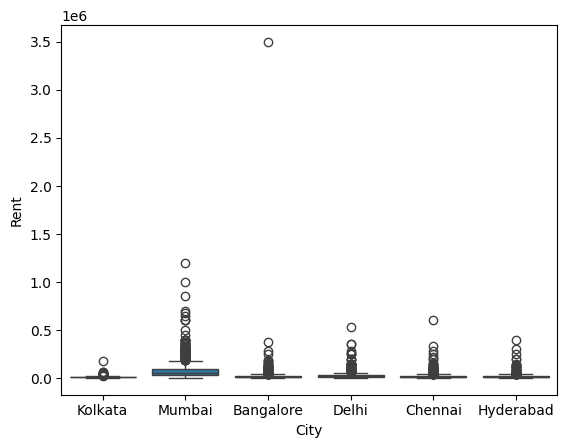

In [42]:
sns.boxplot(x='City', y='Rent', data=df)
plt.show()

In [43]:
df.groupby('City')['Rent'].mean()

City
Bangalore    24966.365688
Chennai      21614.092031
Delhi        29461.983471
Hyderabad    20555.048387
Kolkata      11645.173664
Mumbai       85321.204733
Name: Rent, dtype: float64

==> the target column affected by the City: 'Mumbai' more than the other Cities



In [44]:
# encoding the City column
mapper = {
    'Mumbai': 0,
    'Bangalore': 1,
    'Delhi': 2,
    'Hyderabad': 3,
    'Chennai': 4,
    'Kolkata': 5
}
if (df.City.dtype != 'int64'):
  df['City'] = df['City'].map(mapper)
df.head()

,BHK,Rent,Size,Area_Type,City,Furnishing_Status,Tenant_Preferred,Bathroom,Point_of_Contact
0,2,10000,0.208938,2,5,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,-0.264097,2,5,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,0.051260,2,5,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,-0.264097,2,5,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,-0.185257,0,5,Unfurnished,Bachelors,1,Contact Owner


In [45]:
df.Furnishing_Status.describe()

count               4746
unique                 3
top       Semi-Furnished
freq                2251
Name: Furnishing_Status, dtype: object

In [46]:
df['Furnishing_Status'].value_counts()

Furnishing_Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680
Name: count, dtype: int64

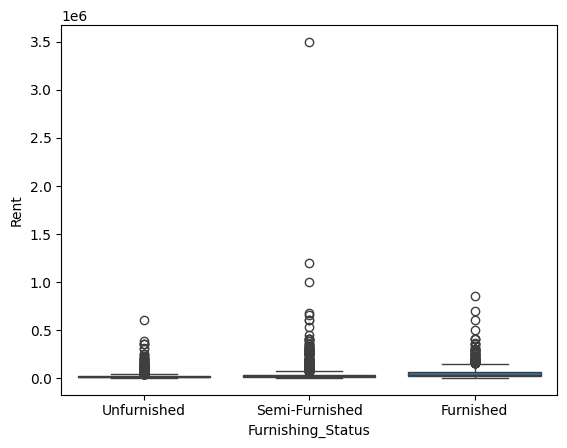

In [47]:
sns.boxplot(x='Furnishing_Status', y='Rent', data=df)
plt.show()

In [48]:
df.groupby('Furnishing_Status')['Rent'].mean()

Furnishing_Status
Furnished         56110.305882
Semi-Furnished    38718.810751
Unfurnished       22461.635813
Name: Rent, dtype: float64

==> the target column affected by the Furnishing_Status: 'Furnished' more than the other

In [49]:
# encoding the Furnishing_Status column
mapper = {
    'Unfurnished': 0,
    'Semi-Furnished': 1,
    'Furnished': 2
}
if (df.Furnishing_Status.dtype != 'int64'):
  df['Furnishing_Status'] = df['Furnishing_Status'].map(mapper)
df.head()

,BHK,Rent,Size,Area_Type,City,Furnishing_Status,Tenant_Preferred,Bathroom,Point_of_Contact
0,2,10000,0.208938,2,5,0,Bachelors/Family,2,Contact Owner
1,2,20000,-0.264097,2,5,1,Bachelors/Family,1,Contact Owner
2,2,17000,0.051260,2,5,1,Bachelors/Family,1,Contact Owner
3,2,10000,-0.264097,2,5,0,Bachelors/Family,1,Contact Owner
4,2,7500,-0.185257,0,5,0,Bachelors,1,Contact Owner


In [50]:
df.Tenant_Preferred.describe()

count                 4746
unique                   3
top       Bachelors/Family
freq                  3444
Name: Tenant_Preferred, dtype: object

In [51]:
df['Tenant_Preferred'].value_counts()

Tenant_Preferred
Bachelors/Family    3444
Bachelors            830
Family               472
Name: count, dtype: int64

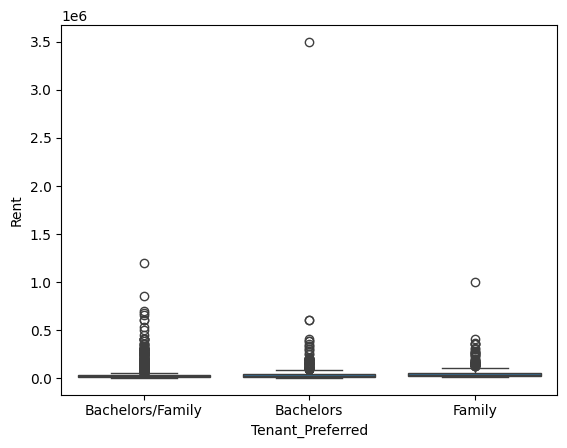

In [52]:
sns.boxplot(x='Tenant_Preferred', y='Rent', data=df)
plt.show()

In [53]:
df.groupby('Tenant_Preferred')['Rent'].mean()

Tenant_Preferred
Bachelors           42143.793976
Bachelors/Family    31210.792683
Family              50020.341102
Name: Rent, dtype: float64

==> the target column affected by the Tenant_Preferred: 'Family' more than the other

In [54]:
# encoding the Tenant_Preferred column
mapper = {
    'Bachelors/Family': 2,
    'Family': 1,
    'Bachelors': 3
}
if (df.Tenant_Preferred.dtype != 'int64'):
  df['Tenant_Preferred'] = df['Tenant_Preferred'].map(mapper)
df.head()

,BHK,Rent,Size,Area_Type,City,Furnishing_Status,Tenant_Preferred,Bathroom,Point_of_Contact
0,2,10000,0.208938,2,5,0,2,2,Contact Owner
1,2,20000,-0.264097,2,5,1,2,1,Contact Owner
2,2,17000,0.051260,2,5,1,2,1,Contact Owner
3,2,10000,-0.264097,2,5,0,2,1,Contact Owner
4,2,7500,-0.185257,0,5,0,3,1,Contact Owner


In [55]:
df.Point_of_Contact.describe()

count              4746
unique                3
top       Contact Owner
freq               3216
Name: Point_of_Contact, dtype: object

In [56]:
df['Point_of_Contact'].value_counts()

Point_of_Contact
Contact Owner      3216
Contact Agent      1529
Contact Builder       1
Name: count, dtype: int64

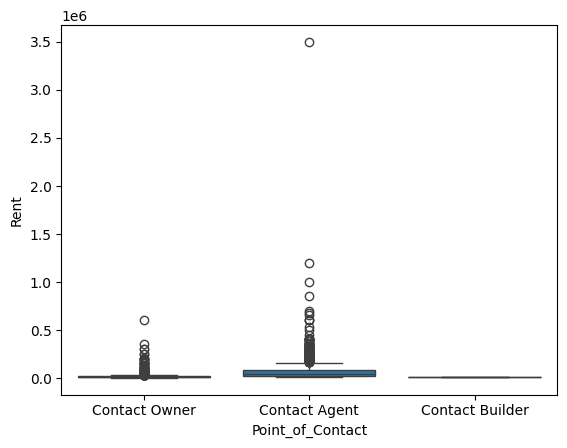

In [57]:
sns.boxplot(x='Point_of_Contact', y='Rent', data=df)
plt.show()

In [58]:
df.groupby('Point_of_Contact')['Rent'].mean()


Point_of_Contact
Contact Agent      73481.158927
Contact Builder     5500.000000
Contact Owner      16704.206468
Name: Rent, dtype: float64

==> the target column affected by the -Point_of_Contact: 'Contact Agent' more than the other.
and also there is a single row that contain the value"Contact Builder" that can be eliminated to make the encoding easier.

In [59]:
df = df[df['Point_of_Contact'] != 'Contact Builder']
df['Point_of_Contact'].value_counts()

Point_of_Contact
Contact Owner    3216
Contact Agent    1529
Name: count, dtype: int64

In [60]:
# encoding the Point_of_Contact column
mapper = {
    'Contact Owner': 1,
    'Contact Agent': 0
}
if (df.Point_of_Contact.dtype != 'int64'):
  df['Point_of_Contact'] = df['Point_of_Contact'].map(mapper)
df.head()

,BHK,Rent,Size,Area_Type,City,Furnishing_Status,Tenant_Preferred,Bathroom,Point_of_Contact
0,2,10000,0.208938,2,5,0,2,2,1
1,2,20000,-0.264097,2,5,1,2,1,1
2,2,17000,0.051260,2,5,1,2,1,1
3,2,10000,-0.264097,2,5,0,2,1,1
4,2,7500,-0.185257,0,5,0,3,1,1


In [61]:
df.Point_of_Contact.dtype

dtype('int64')

Model Training and Evaluating (Linear Regression)

80% training set

20% testing set

In [62]:
X = df.drop(columns=['Rent'])
y = df.Rent

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle=True, random_state = 42)
# random_state ==> set an initial start

In [64]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

model = LinearRegression()  # create model
model.fit(X_train, y_train) # train the model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
model.score(X_test, y_test)

0.46412229207229827

In [66]:
model.coef_

array([  4369.42463722,  16404.15198306,  -3123.18775884,  -7840.21433078,
         3140.36058142,   2929.66346339,  14510.95385571, -21322.33277803])

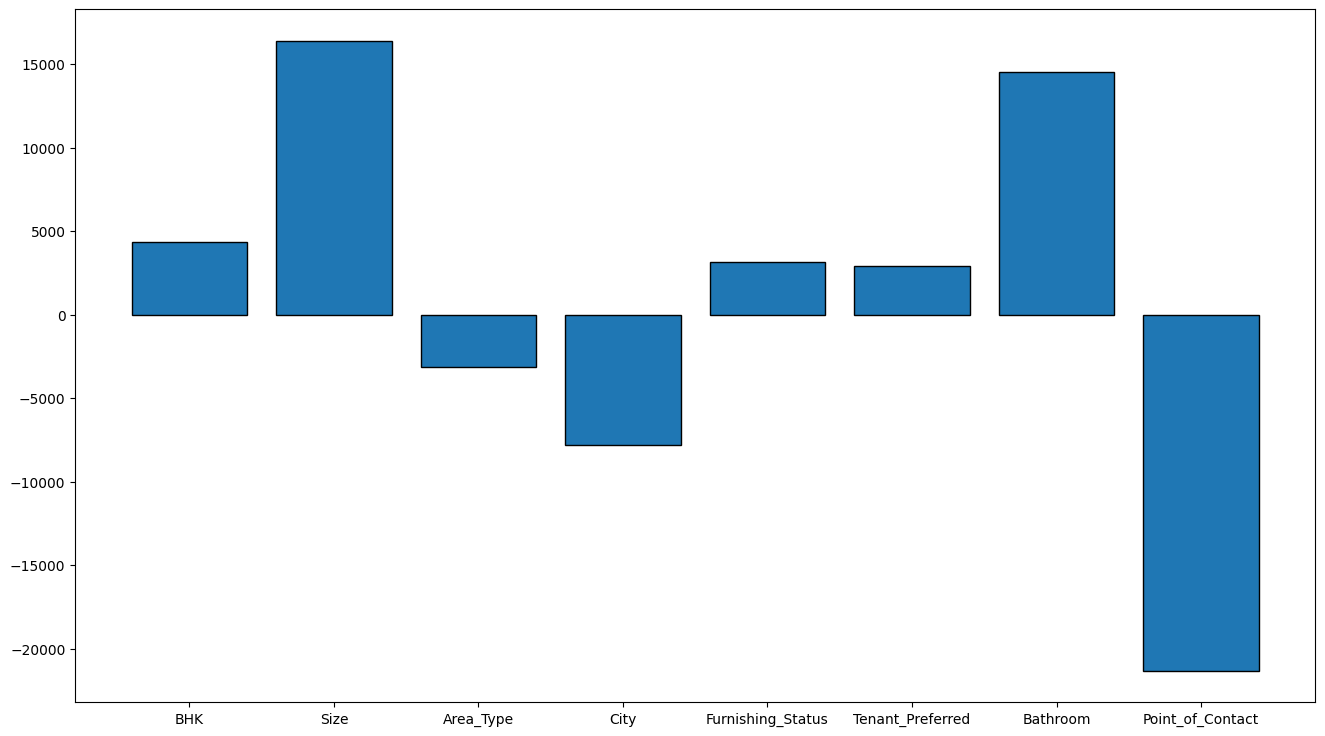

In [67]:
plt.figure(figsize=(16, 9))
plt.bar(x=model.feature_names_in_, height=model.coef_, edgecolor='black')
plt.show()

In [68]:
las_model = Lasso(alpha=1000)
las_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [69]:
las_model.score(X_test, y_test)

0.46318499624531506

In [70]:
las_model.coef_

array([  3329.73348333,  16411.47890347,  -3679.40008581,  -8014.39582722,
         1171.34111106,      0.        ,  14785.31594168, -16635.74141439])